# MetroTransit Fleet – Exploratory Data Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned Bike Sharing dataset.

The analysis focuses on:
- Understanding bike demand patterns
- Studying distributions and skewness
- Observing unusual demand patterns without removing observations
- Finding correlations
- Understanding feature interactions
- Examining category/class distribution
- Identifying actionable insights for bike fleet rebalancing


### Visual EDA Coverage

The notebook includes distribution plots, skewness visualization, numerical boxplots, hourly/seasonal/weekday/monthly demand plots, correlation heatmaps, feature-interaction plots, an hour × working-day heatmap, a casual vs registered rider comparison, and weather-category demand distributions.

## 1. Import Required Libraries

The following libraries are used for data handling, statistical analysis, visualization, and correlation analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats

In [3]:

COLORS = {
    'blue':   '#2F6DB5',
    'orange': '#F28E2B',
    'green':  '#3C9D5D',
    'red':    '#D64550',
    'teal':   '#1B998B',
    'purple': '#7A5AA6',
    'gold':   '#E5B12E',
}
PALETTE   = list(COLORS.values())
TEXT_DARK = '#1F2937'
GRID_GREY = '#E5E9F0'
EDGE_GREY = '#CBD2DC'

# Semantic colours reused across the notebook so the same category always looks the same
DAY_COLORS = {'Non-Working Day': COLORS['orange'], 'Working Day': COLORS['blue']}
WEATHER_ORDER = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow']
WEATHER_COLORS = dict(zip(
    WEATHER_ORDER,
    [COLORS['green'], COLORS['blue'], COLORS['orange'], COLORS['red']]
))

sns.set_theme(style="whitegrid", rc={
    'figure.figsize': (10, 5.5),
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': TEXT_DARK,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelcolor': TEXT_DARK,
    'axes.edgecolor': EDGE_GREY,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'axes.prop_cycle': plt.cycler(color=PALETTE),
    'grid.color': GRID_GREY,
    'grid.linewidth': 0.8,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': EDGE_GREY,
    'legend.facecolor': 'white',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
})


def darken(color, factor=0.6):
    """Return a darker shade of a colour (used for KDE curves)."""
    return tuple(factor * c for c in to_rgb(color))


def style_axes(ax, title, xlabel=None, ylabel=None, grid_axis='y'):
    """Consistent title, labels and light gridlines for every chart."""
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', color=TEXT_DARK, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(False)
    if grid_axis in ('x', 'y'):
        ax.grid(True, axis=grid_axis, color=GRID_GREY, linewidth=0.8)
    elif grid_axis == 'both':
        ax.grid(True, color=GRID_GREY, linewidth=0.8)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def add_legend(ax, handles=None, title=None, loc='best', outside=False, fontsize=10):
    """Clean, boxed legend. outside=True places it to the right of the plot area."""
    kwargs = {'loc': 'center left', 'bbox_to_anchor': (1.02, 0.5)} if outside else {'loc': loc}
    leg = ax.legend(handles=handles, title=title, frameon=True, fancybox=True,
                    framealpha=0.95, edgecolor=EDGE_GREY, facecolor='white',
                    fontsize=fontsize, **kwargs)
    leg.get_title().set_fontweight('bold')
    return leg


def hist_panel(ax, col, color, name, xlabel, title, loc='upper right', fontsize=10, bins=40):
    """Histogram + KDE with mean/median reference lines and a boxed legend."""
    sns.histplot(data=df, x=col, bins=bins, kde=True, color=color, alpha=0.75,
                 edgecolor='white', linewidth=0.6, ax=ax)
    kde_line = ax.lines[0]
    kde_line.set_color(darken(color))
    kde_line.set_linewidth(2.4)

    mean_v, median_v = df[col].mean(), df[col].median()
    ax.axvline(mean_v, color=COLORS['red'], linestyle='--', linewidth=1.8)
    ax.axvline(median_v, color=TEXT_DARK, linestyle=':', linewidth=2)

    handles = [
        Patch(facecolor=color, edgecolor='white', alpha=0.75, label='Histogram'),
        Line2D([0], [0], color=darken(color), linewidth=2.4, label='KDE curve'),
        Line2D([0], [0], color=COLORS['red'], linestyle='--', linewidth=1.8, label=f'Mean = {mean_v:,.2f}'),
        Line2D([0], [0], color=TEXT_DARK, linestyle=':', linewidth=2, label=f'Median = {median_v:,.2f}'),
    ]
    ax.set_ylim(top=ax.get_ylim()[1] * 1.32)   # head-room so the legend never covers the bars
    style_axes(ax, title, xlabel, 'Frequency')
    add_legend(ax, handles, title=name, loc=loc, fontsize=fontsize)

## 2. Load the Cleaned Dataset

Load the cleaned Bike Sharing dataset provided for the project.

In [4]:
df = pd.read_csv("/content/cleaned_bike_sharing.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**DA scope:** The dataset has already been cleaned by the Data Engineering role. This notebook does not perform data cleaning, imputation, transformation, or unusual observation removal. The analysis focuses on understanding patterns in the provided cleaned dataset.


### Dataset Shape and Columns

Check the number of rows, columns, and available features.

In [5]:
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Rows and Columns: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## 3. Basic Dataset Understanding

Before performing EDA, check data types, missing values, duplicate rows, and descriptive statistics.

In [6]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [7]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Define Variables for EDA

The following variables are used for numerical and categorical/time-based analysis.

`cnt` is the total number of bike rentals and is the main demand variable.

In [10]:
numeric_cols = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]

categorical_cols = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]

## 4. Distribution Analysis

Distribution plots help us understand how bike demand and important numerical variables are spread.

We mainly examine `cnt`, `casual`, `registered`, temperature, humidity, and windspeed.

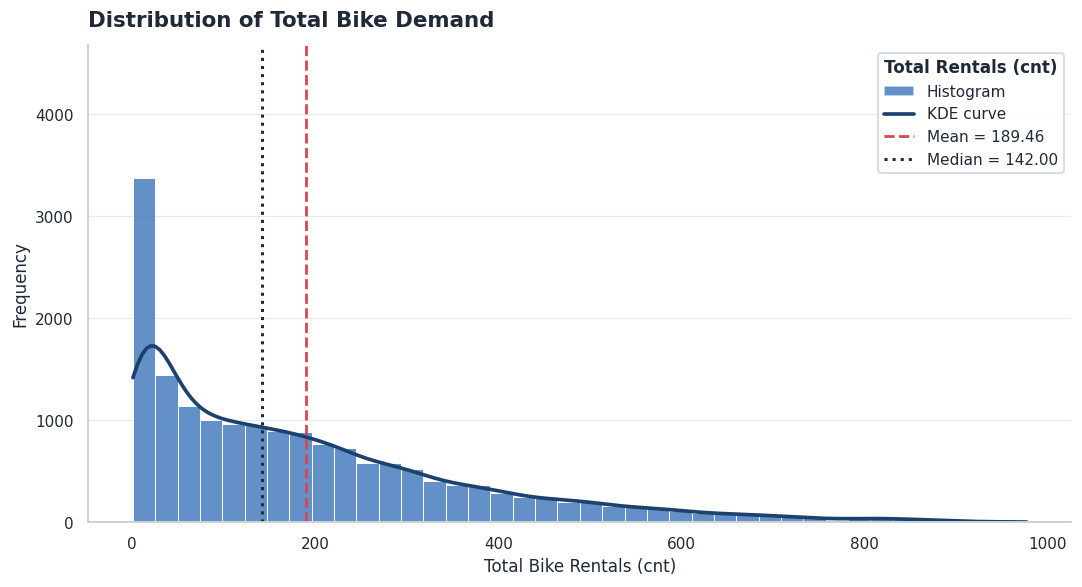

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'cnt', COLORS['blue'], 'Total Rentals (cnt)',
           'Total Bike Rentals (cnt)', 'Distribution of Total Bike Demand', loc='upper right')
plt.tight_layout()
plt.show()

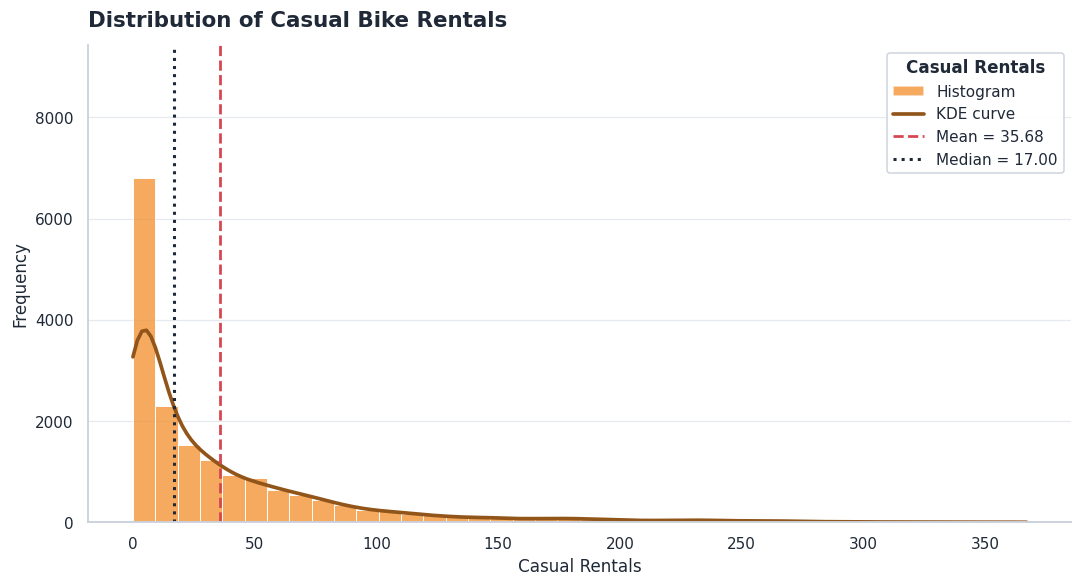

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'casual', COLORS['orange'], 'Casual Rentals',
           'Casual Rentals', 'Distribution of Casual Bike Rentals', loc='upper right')
plt.tight_layout()
plt.show()

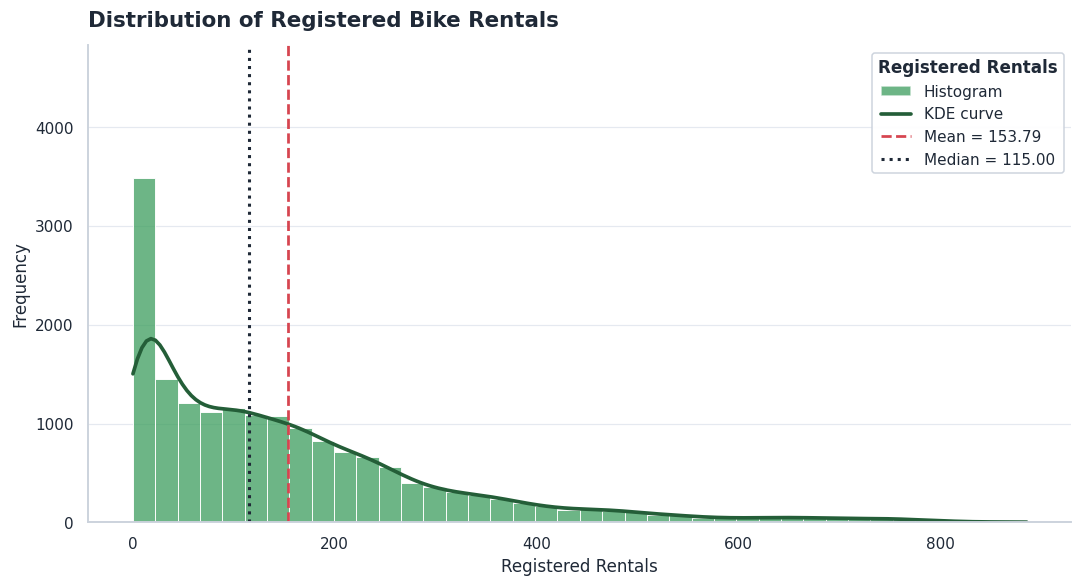

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'registered', COLORS['green'], 'Registered Rentals',
           'Registered Rentals', 'Distribution of Registered Bike Rentals', loc='upper right')
plt.tight_layout()
plt.show()

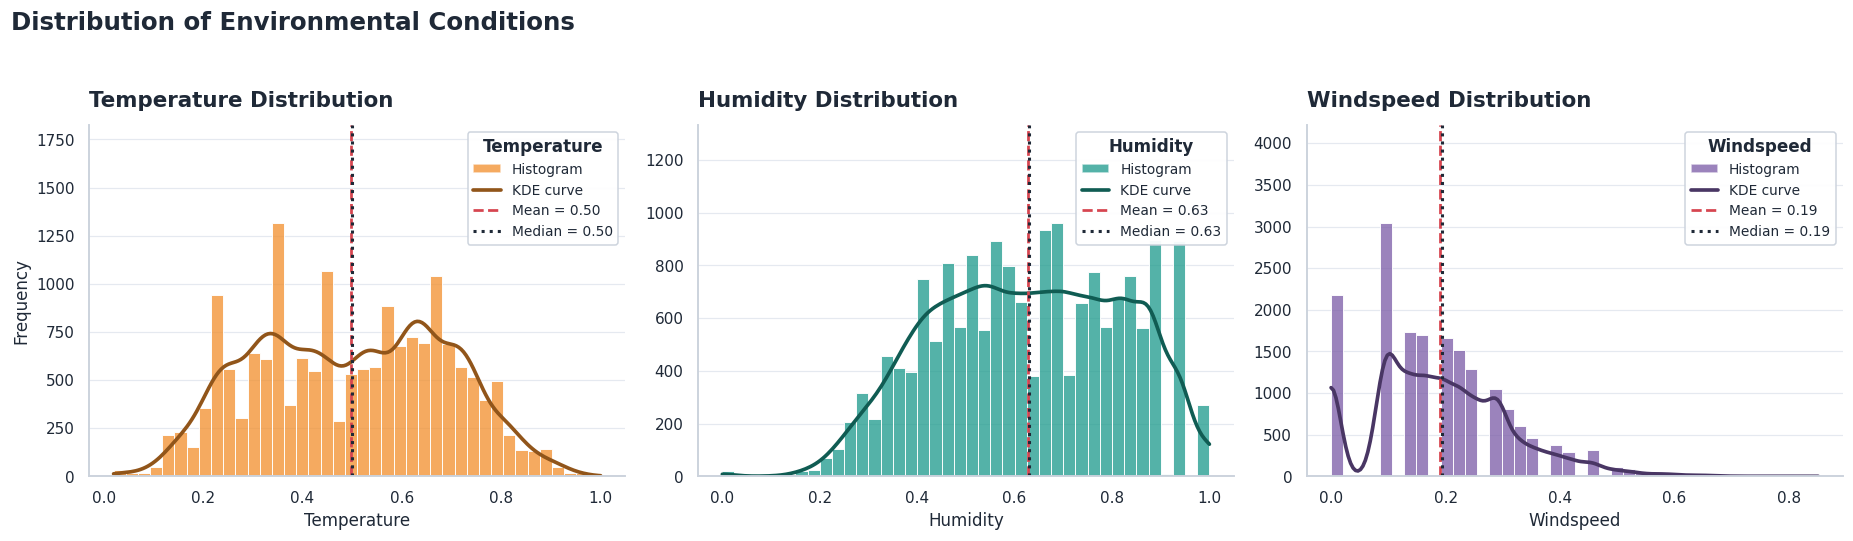

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

hist_panel(axes[0], 'temp', COLORS['orange'], 'Temperature',
           'Temperature', 'Temperature Distribution', fontsize=9)
hist_panel(axes[1], 'hum', COLORS['teal'], 'Humidity',
           'Humidity', 'Humidity Distribution', fontsize=9)
hist_panel(axes[2], 'windspeed', COLORS['purple'], 'Windspeed',
           'Windspeed', 'Windspeed Distribution', fontsize=9)

for ax in axes[1:]:
    ax.set_ylabel('')

fig.suptitle('Distribution of Environmental Conditions', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Distribution Interpretation

Bike demand variables are generally right-skewed, meaning that many observations have relatively lower demand while a smaller number of observations have very high demand.

These high-demand observations should not automatically be removed because they may represent genuine peak-demand periods.

## 5. Skewness Analysis

Skewness measures the asymmetry of a distribution.

- Skewness > 0.5 → Right-skewed
- Skewness < -0.5 → Left-skewed
- Between -0.5 and 0.5 → Approximately symmetric

In [15]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness

,0
casual,2.499237
registered,1.557904
cnt,1.277412
windspeed,0.574905
temp,-0.006021
atemp,-0.090429
hum,-0.111287


In [16]:
skewness_table = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

skewness_table['Interpretation'] = skewness_table['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 0.5
    else ('Left-skewed' if x < -0.5 else 'Approximately symmetric')
)

skewness_table

,Feature,Skewness,Interpretation
0,casual,2.499237,Right-skewed
1,registered,1.557904,Right-skewed
2,cnt,1.277412,Right-skewed
3,windspeed,0.574905,Right-skewed
4,temp,-0.006021,Approximately symmetric
5,atemp,-0.090429,Approximately symmetric
6,hum,-0.111287,Approximately symmetric


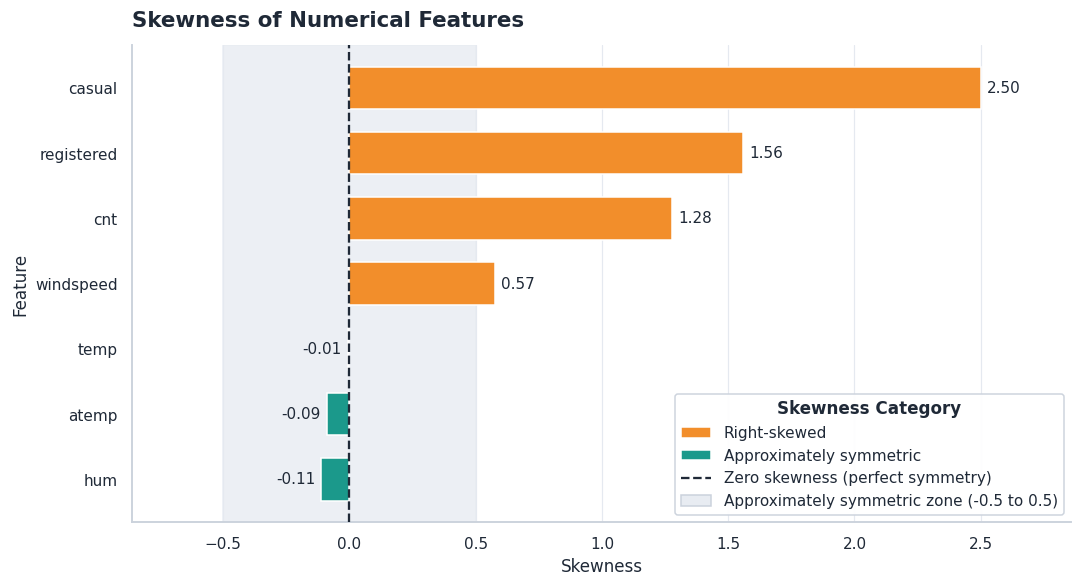

In [17]:
skew_colors = {
    'Right-skewed': COLORS['orange'],
    'Left-skewed': COLORS['purple'],
    'Approximately symmetric': COLORS['teal'],
}
SYM_ZONE = '#E8ECF2'

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 0.5, color=SYM_ZONE, alpha=0.8, zorder=0)
bars = ax.barh(
    skewness_table['Feature'], skewness_table['Skewness'],
    color=skewness_table['Interpretation'].map(skew_colors).tolist(),
    edgecolor='white', height=0.65, zorder=2
)
ax.axvline(0, color=TEXT_DARK, linestyle='--', linewidth=1.5, zorder=3)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10, color=TEXT_DARK)
ax.invert_yaxis()
ax.margins(x=0.12)
style_axes(ax, 'Skewness of Numerical Features', 'Skewness', 'Feature', grid_axis='x')

present = set(skewness_table['Interpretation'])
handles = [Patch(facecolor=c, label=k) for k, c in skew_colors.items() if k in present]
handles += [
    Line2D([0], [0], color=TEXT_DARK, linestyle='--', linewidth=1.5, label='Zero skewness (perfect symmetry)'),
    Patch(facecolor=SYM_ZONE, edgecolor=EDGE_GREY, label='Approximately symmetric zone (-0.5 to 0.5)'),
]
add_legend(ax, handles, title='Skewness Category', loc='lower right')
plt.tight_layout()
plt.show()

### Key Skewness Observation

`casual`, `registered`, and `cnt` show positive/right skewness. This indicates the presence of relatively high-demand observations.

Temperature, humidity, and windspeed are much closer to symmetric distributions.

## 6. Numerical Feature Boxplots

Boxplots provide a visual view of the spread, median, and potential extreme observations in the main numerical variables. Since the dataset has already been cleaned by the Data Engineering role, these observations are **not removed** here.

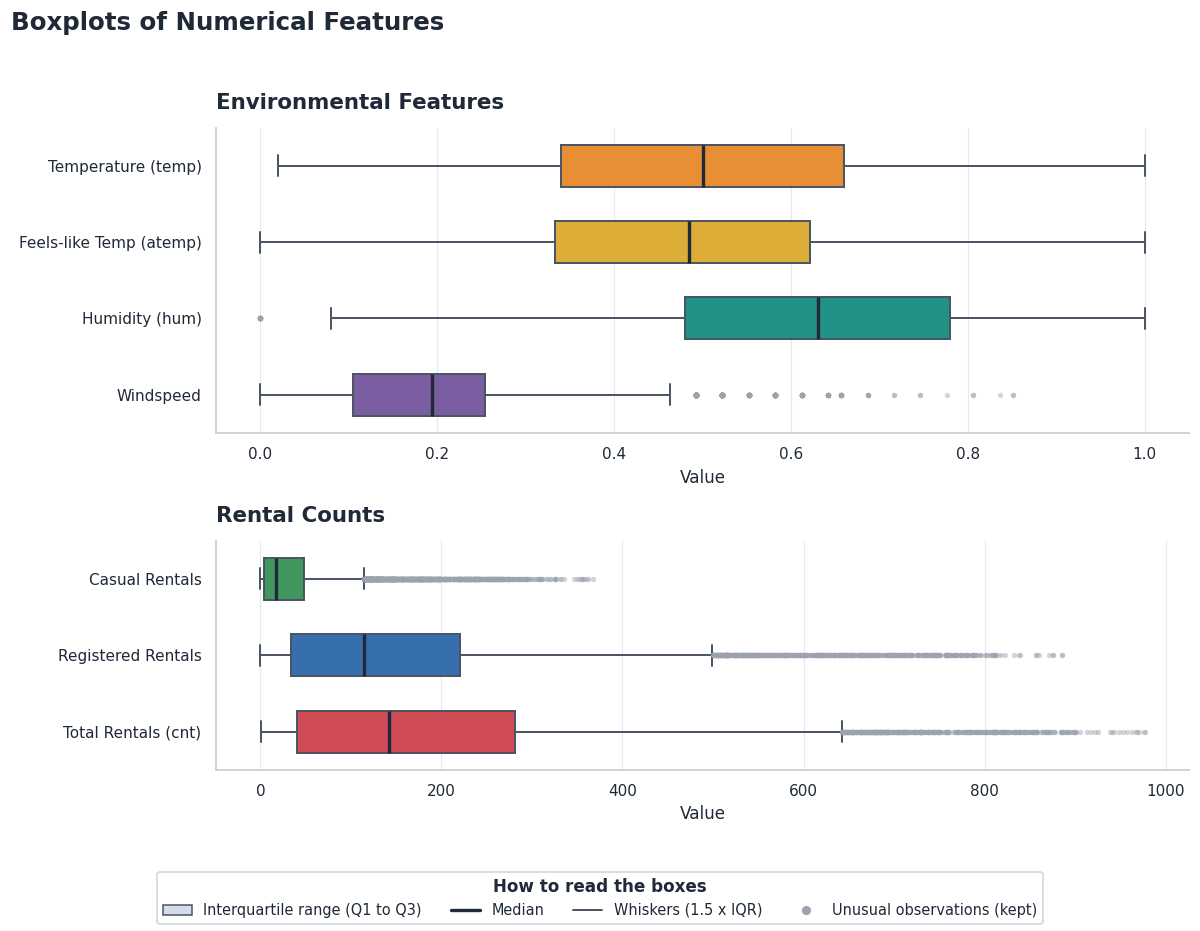

In [18]:
plot_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

box_labels = {
    'temp': 'Temperature (temp)',
    'atemp': 'Feels-like Temp (atemp)',
    'hum': 'Humidity (hum)',
    'windspeed': 'Windspeed',
    'casual': 'Casual Rentals',
    'registered': 'Registered Rentals',
    'cnt': 'Total Rentals (cnt)',
}
box_colors = dict(zip(
    plot_cols,
    [COLORS['orange'], COLORS['gold'], COLORS['teal'], COLORS['purple'],
     COLORS['green'], COLORS['blue'], COLORS['red']]
))
# Two panels because the weather variables and the rental counts are on very different scales
box_groups = [
    ('Environmental Features', ['temp', 'atemp', 'hum', 'windspeed']),
    ('Rental Counts', ['casual', 'registered', 'cnt']),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), gridspec_kw={'height_ratios': [4, 3]})

for ax, (group_title, cols) in zip(axes, box_groups):
    long_df = df[cols].rename(columns=box_labels).melt(var_name='Feature', value_name='Value')
    order = [box_labels[c] for c in cols]
    sns.boxplot(
        data=long_df, x='Value', y='Feature', hue='Feature',
        order=order, hue_order=order,
        palette={box_labels[c]: box_colors[c] for c in cols},
        orient='h', legend=False, width=0.55, linewidth=1.3, saturation=0.9,
        linecolor='#4B5563',
        medianprops={'color': TEXT_DARK, 'linewidth': 2.2},
        flierprops={'marker': 'o', 'markerfacecolor': '#9CA3AF', 'markeredgecolor': 'none',
                    'markersize': 3.5, 'alpha': 0.45},
        ax=ax
    )
    style_axes(ax, group_title, 'Value', '', grid_axis='x')

fig.suptitle('Boxplots of Numerical Features', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)

legend_handles = [
    Patch(facecolor='#D5DDEA', edgecolor='#4B5563', label='Interquartile range (Q1 to Q3)'),
    Line2D([0], [0], color=TEXT_DARK, linewidth=2.2, label='Median'),
    Line2D([0], [0], color='#4B5563', linewidth=1.3, label='Whiskers (1.5 x IQR)'),
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#9CA3AF',
           markeredgecolor='none', markersize=6, label='Unusual observations (kept)'),
]
leg = fig.legend(handles=legend_handles, loc='lower center', ncol=4, title='How to read the boxes',
                 frameon=True, fancybox=True, edgecolor=EDGE_GREY, facecolor='white', fontsize=9.5)
leg.get_title().set_fontweight('bold')

plt.tight_layout(rect=[0, 0.09, 1, 0.96])
plt.show()

### Boxplot Interpretation

The boxplots show the central range and spread of the numerical features and make unusually high or low observations easy to identify visually. Some variables, particularly the rental-count variables, may show wider spread and more extreme values because demand varies substantially across different periods. These observations are retained because they can represent genuine peak-demand periods rather than data errors.

## 7. Temporal Demand Analysis

Bike demand can change substantially depending on the time of day, season, and whether the day is a working day.

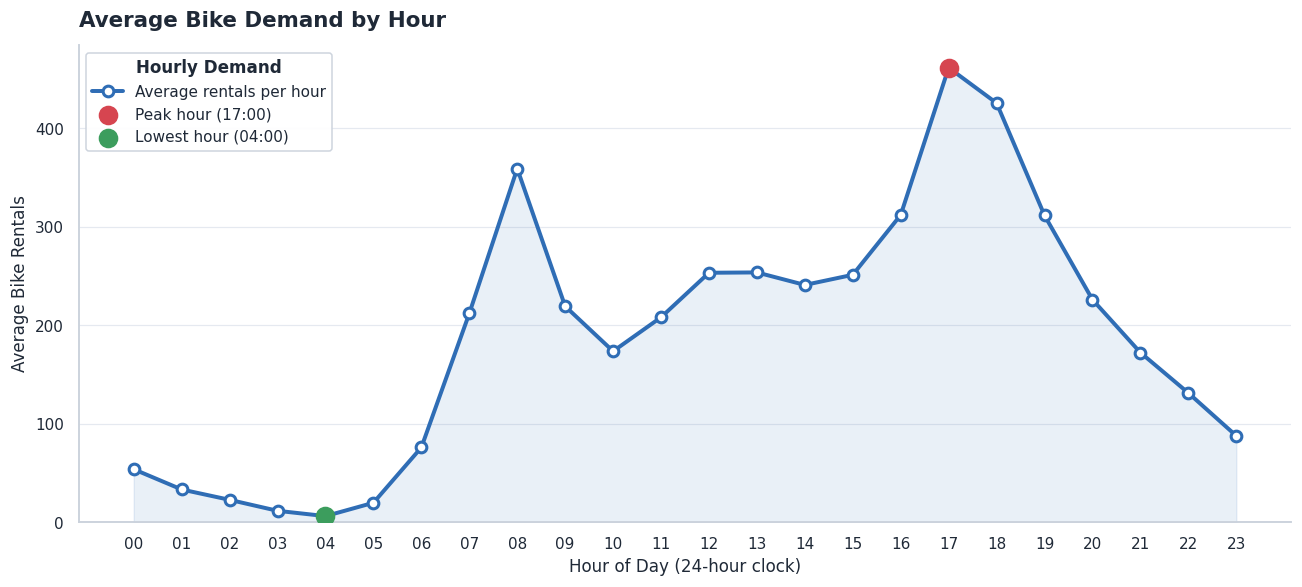

In [19]:
hourly_demand = df.groupby('hr')['cnt'].mean()
peak_hr, low_hr = hourly_demand.idxmax(), hourly_demand.idxmin()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(hourly_demand.index, hourly_demand.values, color=COLORS['blue'], linewidth=2.6,
        marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2,
        label='Average rentals per hour')
ax.fill_between(hourly_demand.index, hourly_demand.values, color=COLORS['blue'], alpha=0.10)
ax.scatter(peak_hr, hourly_demand[peak_hr], s=140, color=COLORS['red'], zorder=5,
           label=f'Peak hour ({peak_hr:02d}:00)')
ax.scatter(low_hr, hourly_demand[low_hr], s=140, color=COLORS['green'], zorder=5,
           label=f'Lowest hour ({low_hr:02d}:00)')

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Average Bike Demand by Hour', 'Hour of Day (24-hour clock)', 'Average Bike Rentals')
add_legend(ax, title='Hourly Demand', loc='upper left')
plt.tight_layout()
plt.show()

### Hourly Demand Interpretation

Demand is not uniform throughout the day. The dataset shows strong differences between low-demand and high-demand hours.

The highest average demand occurs around **17:00**, while the lowest occurs around **04:00**.

This is useful for planning fleet availability and rebalancing.

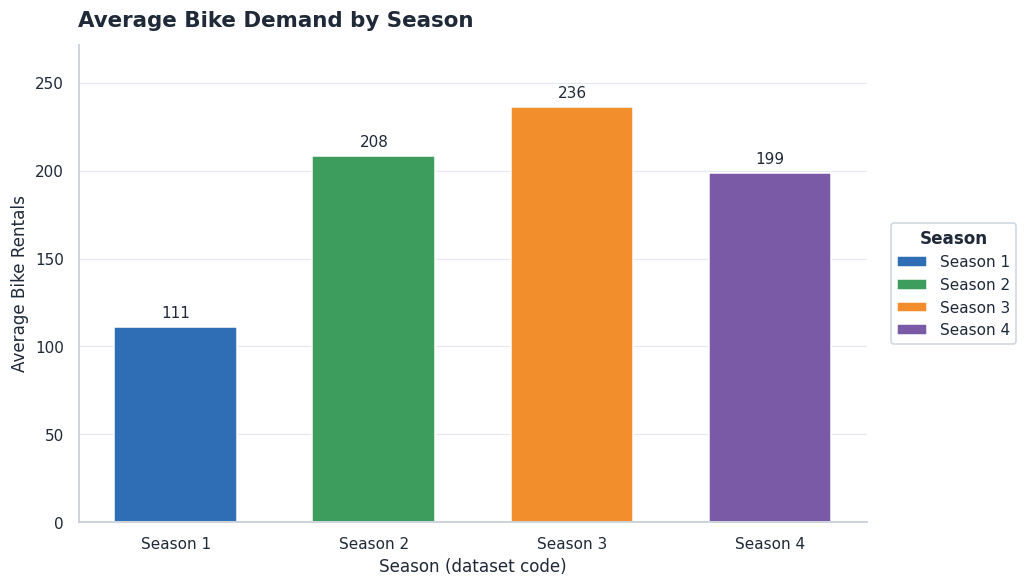

In [20]:
season_demand = df.groupby('season')['cnt'].mean()
season_labels = [f'Season {s}' for s in season_demand.index]
season_colors = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['purple']][:len(season_labels)]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(season_labels, season_demand.values, color=season_colors, edgecolor='white', width=0.62)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, season_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Season', 'Season (dataset code)', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=l) for c, l in zip(season_colors, season_labels)],
           title='Season', outside=True)
plt.tight_layout()
plt.show()

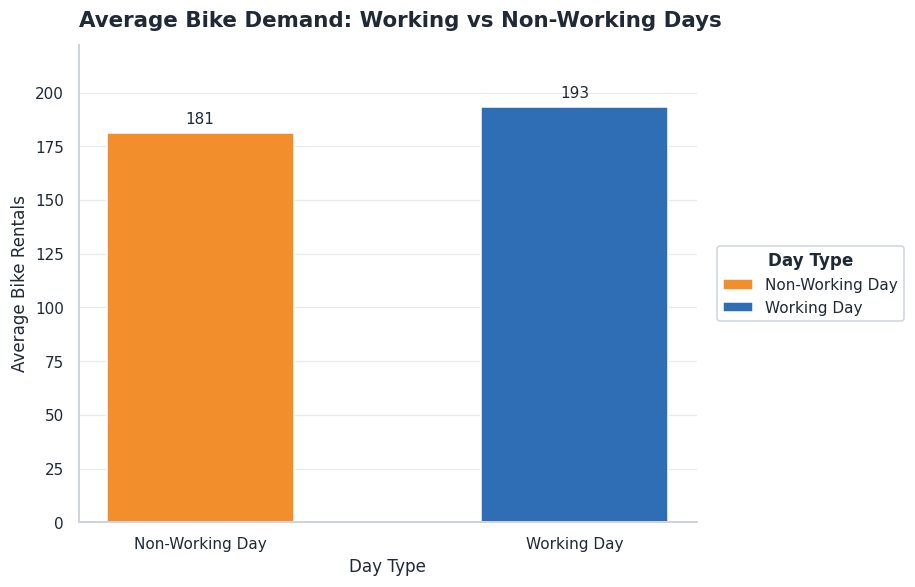

In [21]:
workingday_demand = df.groupby('workingday')['cnt'].mean()
day_labels = ['Working Day' if d == 1 else 'Non-Working Day' for d in workingday_demand.index]
day_colors = [DAY_COLORS[l] for l in day_labels]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(day_labels, workingday_demand.values, color=day_colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, workingday_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand: Working vs Non-Working Days', 'Day Type', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=l) for l, c in zip(day_labels, day_colors)],
           title='Day Type', outside=True)
plt.tight_layout()
plt.show()

### Average Demand by Weekday

Weekday-level analysis provides a more detailed view than the working-day/non-working-day comparison alone.

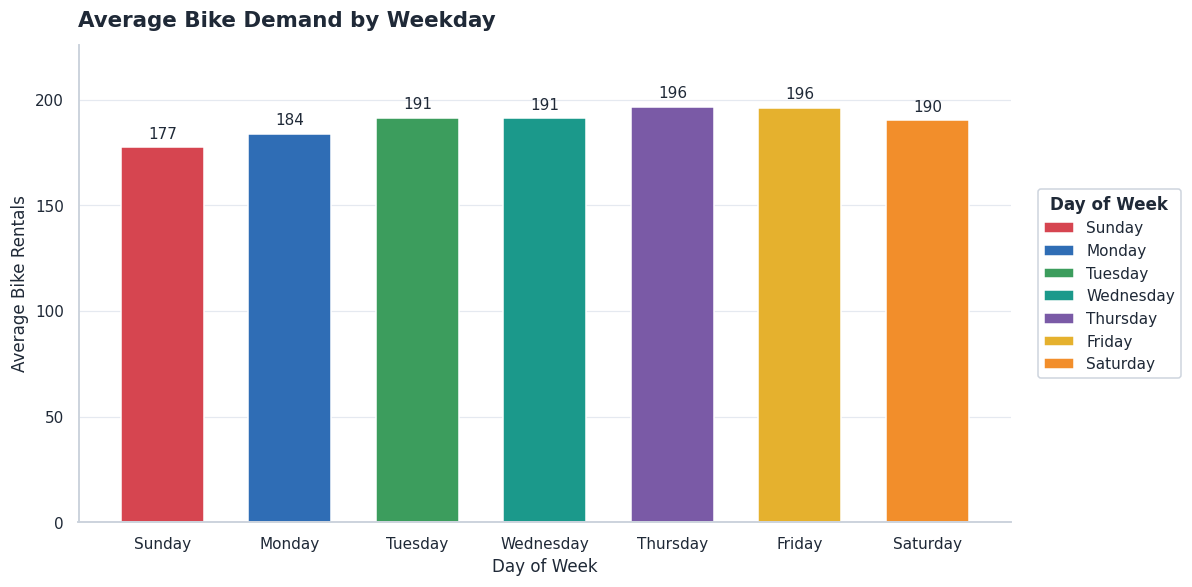

In [22]:
weekday_labels = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

weekday_demand = (
    df.groupby('weekday')['cnt']
    .mean()
    .reindex(range(7))
)

weekday_names = [weekday_labels[i] for i in weekday_demand.index]
weekday_colors = [COLORS['red'], COLORS['blue'], COLORS['green'], COLORS['teal'],
                  COLORS['purple'], COLORS['gold'], COLORS['orange']]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(weekday_names, weekday_demand.values, color=weekday_colors, edgecolor='white', width=0.65)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, weekday_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Weekday', 'Day of Week', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=n) for c, n in zip(weekday_colors, weekday_names)],
           title='Day of Week', outside=True)
plt.tight_layout()
plt.show()

### Weekday Interpretation

Average bike demand differs across the days of the week. This gives a more detailed operational view than simply separating working and non-working days and can help identify days that may require different fleet availability or rebalancing levels.

### Average Demand by Month

Monthly demand helps identify longer-term changes in usage across the year.

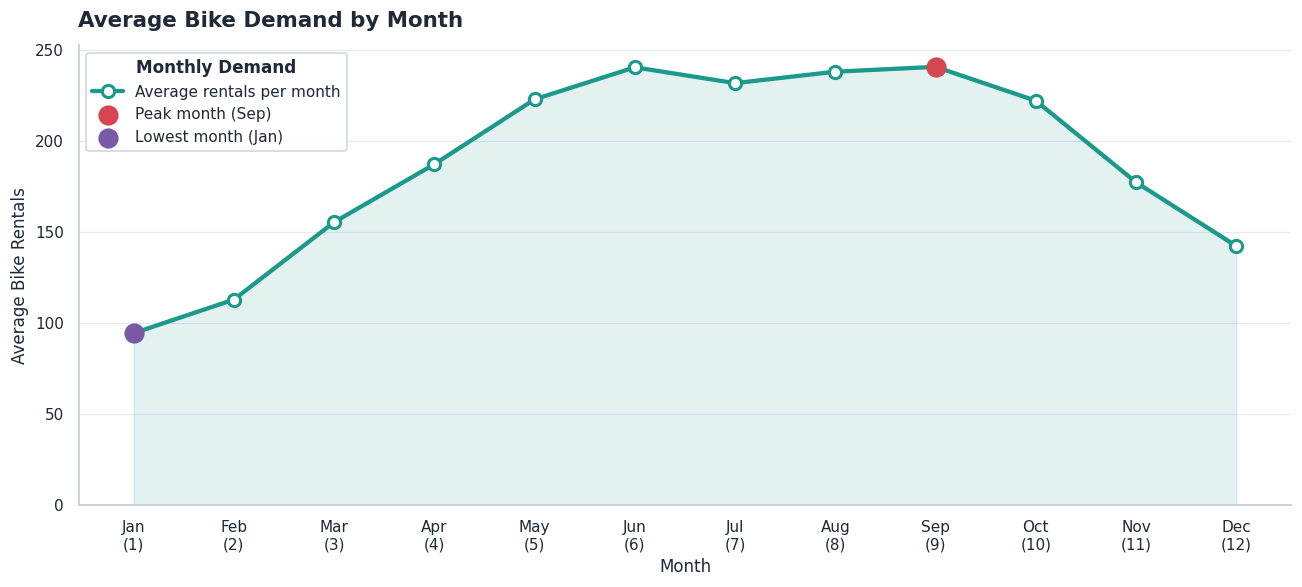

In [23]:
month_demand = (
    df.groupby('mnth')['cnt']
    .mean()
    .reindex(range(1, 13))
)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
peak_m, low_m = month_demand.idxmax(), month_demand.idxmin()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(month_demand.index, month_demand.values, color=COLORS['teal'], linewidth=2.8,
        solid_joinstyle='round', marker='o', markersize=8, markerfacecolor='white',
        markeredgewidth=2, label='Average rentals per month')
ax.fill_between(month_demand.index, month_demand.values, color=COLORS['teal'], alpha=0.12)
ax.scatter(peak_m, month_demand[peak_m], s=150, color=COLORS['red'], zorder=5,
           label=f'Peak month ({month_names[peak_m - 1]})')
ax.scatter(low_m, month_demand[low_m], s=150, color=COLORS['purple'], zorder=5,
           label=f'Lowest month ({month_names[low_m - 1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}\n({i})' for i, m in enumerate(month_names, start=1)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Average Bike Demand by Month', 'Month', 'Average Bike Rentals')
add_legend(ax, title='Monthly Demand', loc='upper left')
plt.tight_layout()
plt.show()

### Monthly Interpretation

The monthly pattern shows that average bike demand changes over the year rather than remaining constant. This indicates that fleet planning can benefit from considering seasonal or monthly demand patterns in addition to hourly patterns.

## 8. Correlation Analysis

Correlation measures the strength and direction of association between numerical variables.

- Positive correlation → variables tend to increase together
- Negative correlation → one tends to increase as the other decreases
- Correlation does **not** prove causation

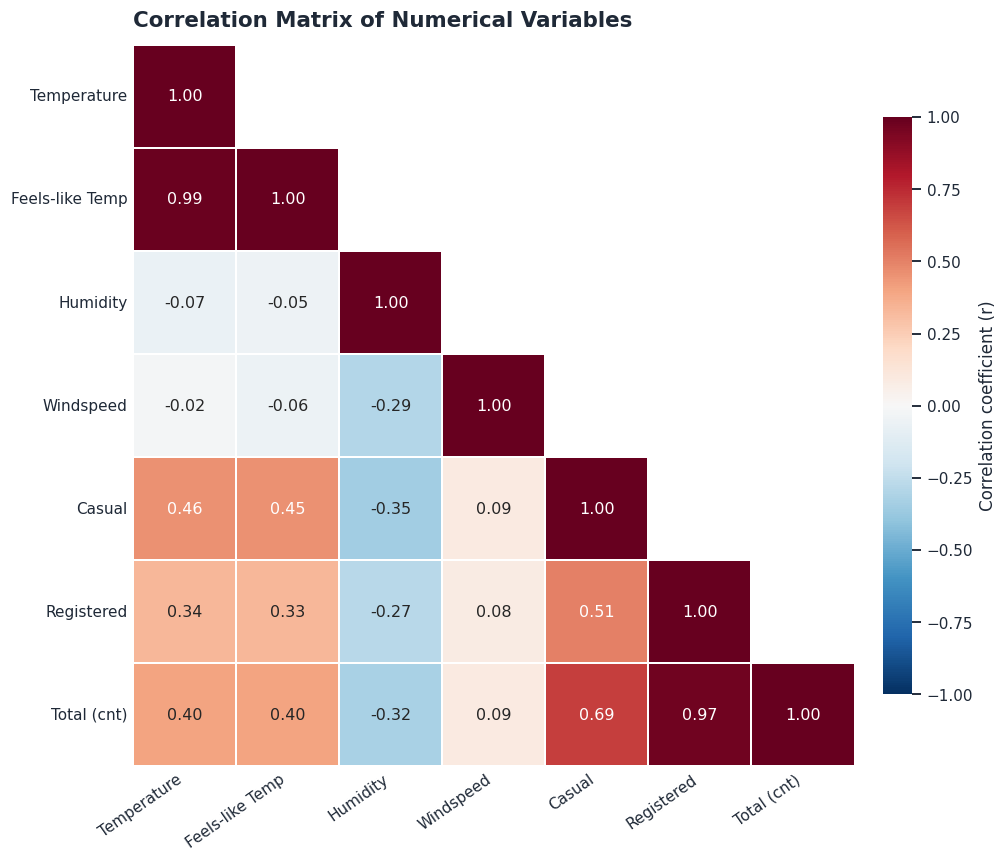

In [24]:
corr = df[numeric_cols].corr()

feature_names = {
    'temp': 'Temperature',
    'atemp': 'Feels-like Temp',
    'hum': 'Humidity',
    'windspeed': 'Windspeed',
    'casual': 'Casual',
    'registered': 'Registered',
    'cnt': 'Total (cnt)',
}
corr_plot = corr.rename(index=feature_names, columns=feature_names)
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)   # show lower triangle only

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_plot, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 10.5},
    linewidths=1.2, linecolor='white', square=True,
    cbar_kws={'label': 'Correlation coefficient (r)', 'shrink': 0.8, 'pad': 0.03},
    ax=ax
)
ax.set_title('Correlation Matrix of Numerical Variables', loc='left', fontsize=14,
             fontweight='bold', color=TEXT_DARK, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(False)
ax.tick_params(length=0)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Correlation with Bike Demand

The next analysis specifically examines how each numerical feature is associated with total bike demand (`cnt`).

In [25]:
target_corr = (
    df[numeric_cols]
    .corr()['cnt']
    .drop('cnt')
    .sort_values(key=abs, ascending=False)
)

target_corr

,cnt
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hum,-0.322911
windspeed,0.093234


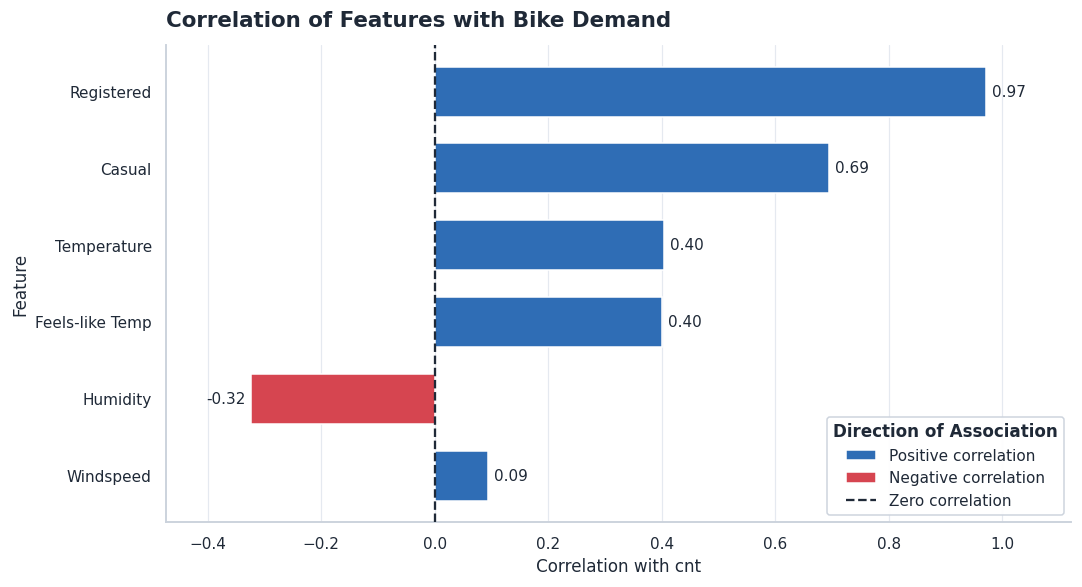

In [26]:
tc_labels = [feature_names.get(i, i) for i in target_corr.index]
tc_colors = [COLORS['blue'] if v >= 0 else COLORS['red'] for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(tc_labels, target_corr.values, color=tc_colors, edgecolor='white', height=0.65, zorder=2)
ax.axvline(0, color=TEXT_DARK, linestyle='--', linewidth=1.5, zorder=3)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10, color=TEXT_DARK)
ax.invert_yaxis()
ax.set_xlim(min(target_corr.min(), 0) - 0.15, max(target_corr.max(), 0) + 0.15)
style_axes(ax, 'Correlation of Features with Bike Demand', 'Correlation with cnt', 'Feature', grid_axis='x')

handles = [
    Patch(facecolor=COLORS['blue'], label='Positive correlation'),
    Patch(facecolor=COLORS['red'], label='Negative correlation'),
    Line2D([0], [0], color=TEXT_DARK, linestyle='--', linewidth=1.5, label='Zero correlation'),
]
add_legend(ax, handles, title='Direction of Association', loc='lower right')
plt.tight_layout()
plt.show()

### Correlation Interpretation

Important relationships with total demand include:

- `registered` has a very strong positive association with `cnt`.
- `casual` has a strong positive association with `cnt`.
- `temp` has a moderate positive association with `cnt`.
- `hum` has a negative association with `cnt`.
- `weathersit` has a negative association with `cnt`.

These are associations in the observed dataset and should not be interpreted as proof of causation.

In [27]:
weather_labels = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

df['weather_label'] = df['weathersit'].map(weather_labels)

## 9. Feature Interaction Analysis

Feature interactions help us understand whether the effect of one variable changes depending on another variable.

We examine:
1. Temperature and demand
2. Hour and working-day status
3. Casual vs registered riders by hour and day type
4. Weather and demand

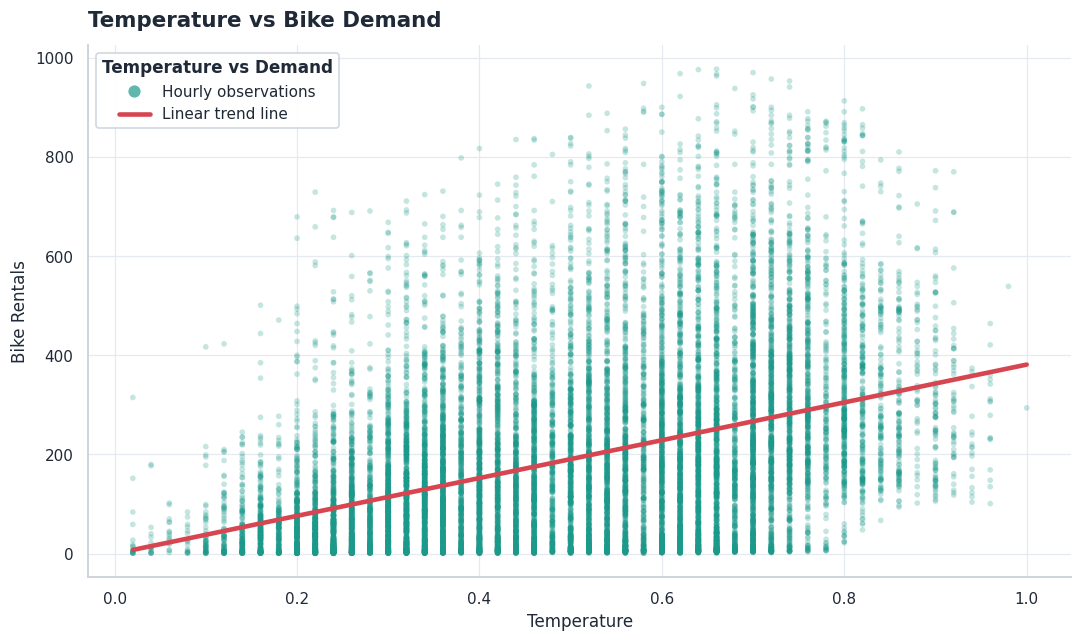

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['temp'], df['cnt'], s=14, color=COLORS['teal'], alpha=0.25, edgecolor='none')
sns.regplot(data=df, x='temp', y='cnt', scatter=False, ci=None,
            line_kws={'color': COLORS['red'], 'linewidth': 3}, ax=ax)

handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COLORS['teal'],
           markeredgecolor='none', markersize=8, alpha=0.7, label='Hourly observations'),
    Line2D([0], [0], color=COLORS['red'], linewidth=3, label='Linear trend line'),
]
style_axes(ax, 'Temperature vs Bike Demand', 'Temperature', 'Bike Rentals', grid_axis='both')
add_legend(ax, handles, title='Temperature vs Demand', loc='upper left')
plt.tight_layout()
plt.show()

### Hour × Working-Day Demand Heatmap

A heatmap makes it easier to identify combinations of hour and working-day status where average demand is relatively high or low.

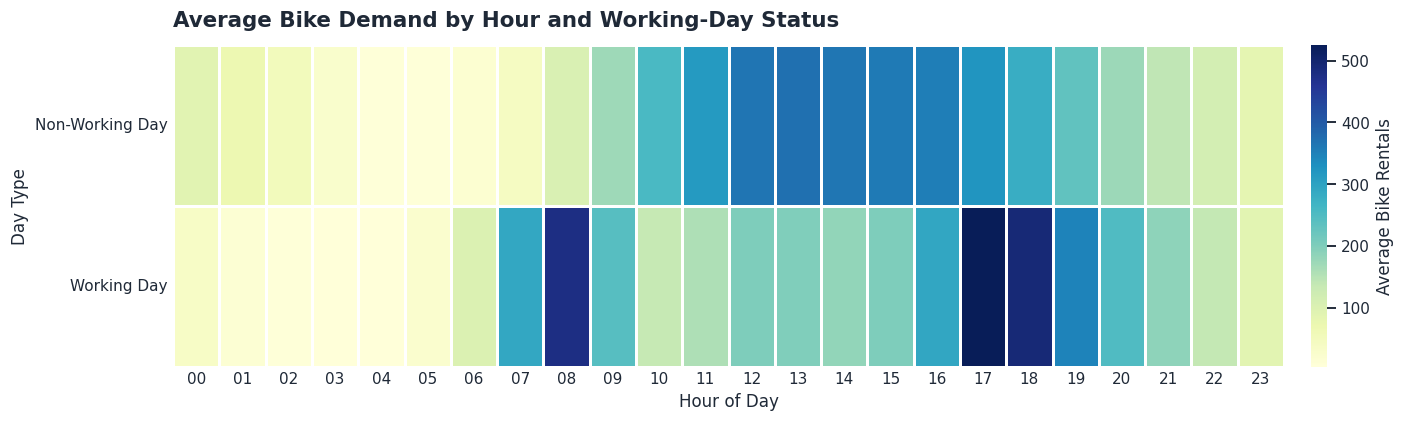

In [29]:
hour_working_pivot = (
    df.pivot_table(
        index='workingday',
        columns='hr',
        values='cnt',
        aggfunc='mean'
    )
)

hour_working_pivot.index = ['Non-Working Day', 'Working Day']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    hour_working_pivot,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Average Bike Rentals', 'pad': 0.02},
    ax=ax
)
ax.set_title('Average Bike Demand by Hour and Working-Day Status', loc='left',
             fontsize=14, fontweight='bold', color=TEXT_DARK, pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day Type')
ax.set_xticklabels([f'{int(h):02d}' for h in hour_working_pivot.columns], rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
ax.grid(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

### Heatmap Interpretation

The heatmap highlights how demand changes jointly across the hour of day and working-day status. Differences between the two day types are especially useful for identifying time periods where fleet rebalancing requirements may need to follow different patterns.

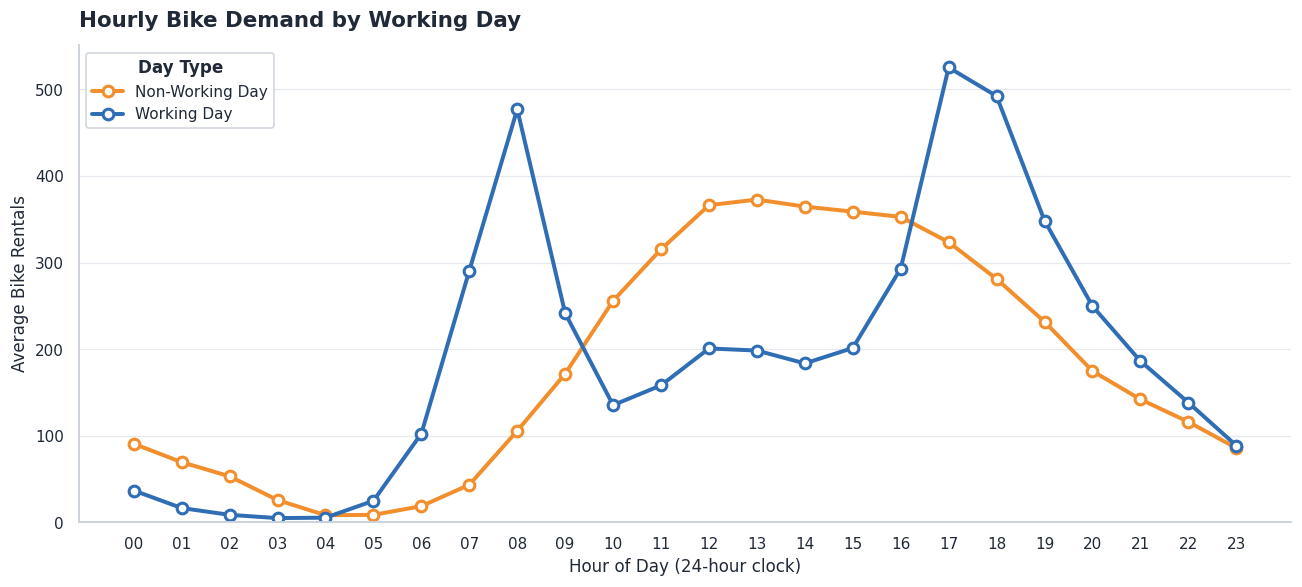

In [30]:
hour_working = (
    df.groupby(['hr', 'workingday'])['cnt']
    .mean()
    .reset_index()
)
hour_working['day_type'] = hour_working['workingday'].map({0: 'Non-Working Day', 1: 'Working Day'})

fig, ax = plt.subplots(figsize=(12, 5.5))
for day_type, color in DAY_COLORS.items():
    sub = hour_working[hour_working['day_type'] == day_type]
    ax.plot(sub['hr'], sub['cnt'], color=color, linewidth=2.6, marker='o', markersize=7,
            markerfacecolor='white', markeredgewidth=2, label=day_type)

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Hourly Bike Demand by Working Day', 'Hour of Day (24-hour clock)', 'Average Bike Rentals')
add_legend(ax, title='Day Type', loc='upper left')
plt.tight_layout()
plt.show()

### Casual vs Registered Riders by Hour and Day Type

The total-demand curves can hide the fact that two different rider groups (`registered` and `casual`) may use the system for different purposes. Splitting demand by rider type shows whether the working-day and non-working-day patterns are driven by the same group of users.

In [31]:
user_hour = (
    df.groupby(['workingday', 'hr'])[['casual', 'registered']]
    .mean()
    .reset_index()
)

rows = []
for wd, label in [(0, 'Non-Working Day'), (1, 'Working Day')]:
    sub = user_hour[user_hour['workingday'] == wd]
    day_df = df[df['workingday'] == wd]
    rows.append({
        'Day Type': label,
        'Casual Peak Hour': int(sub.loc[sub['casual'].idxmax(), 'hr']),
        'Registered Peak Hour': int(sub.loc[sub['registered'].idxmax(), 'hr']),
        'Avg Casual per Hour': round(day_df['casual'].mean(), 2),
        'Avg Registered per Hour': round(day_df['registered'].mean(), 2),
        'Casual Share of Rentals (%)': round(100 * day_df['casual'].sum() / day_df['cnt'].sum(), 1),
    })

rider_type_summary = pd.DataFrame(rows)
rider_type_summary

,Day Type,Casual Peak Hour,Registered Peak Hour,Avg Casual per Hour,Avg Registered per Hour,Casual Share of Rentals (%)
0,Non-Working Day,14,12,57.44,123.96,31.7
1,Working Day,17,17,25.56,167.65,13.2


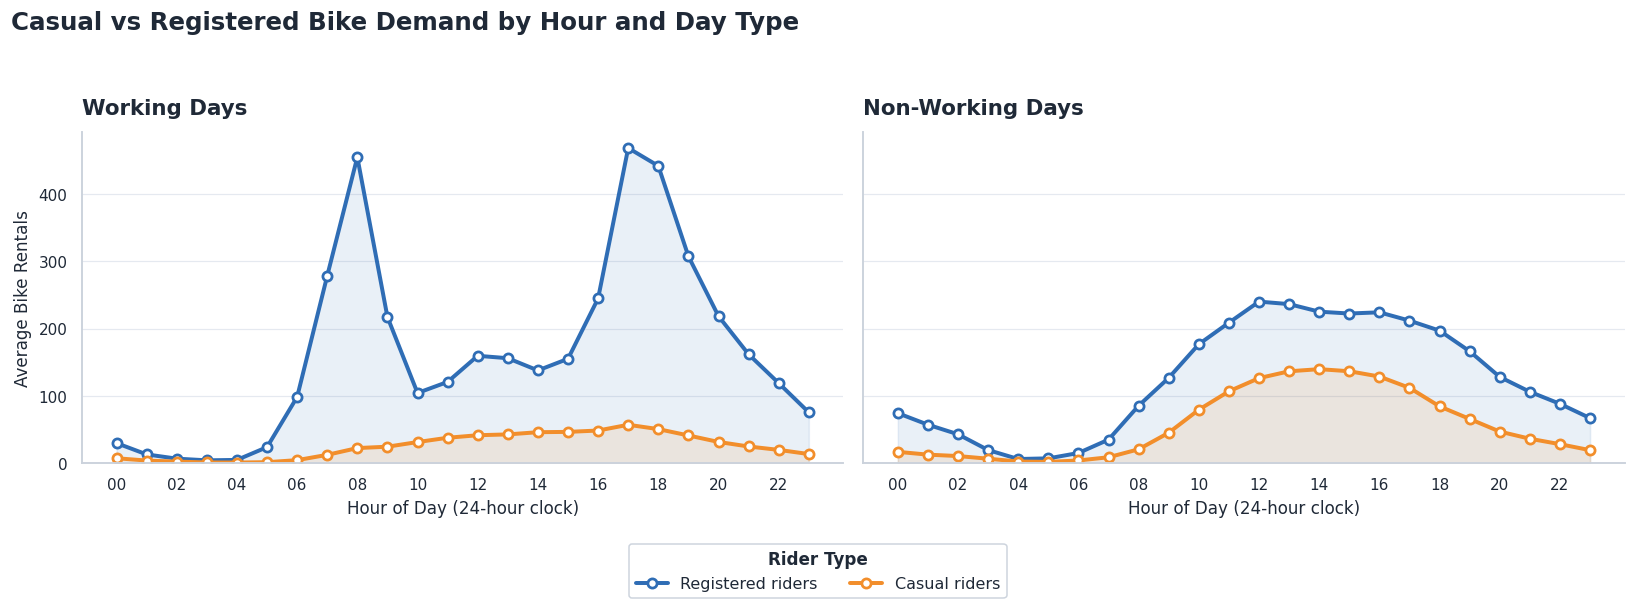

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, (wd, panel_title) in zip(axes, [(1, 'Working Days'), (0, 'Non-Working Days')]):
    sub = user_hour[user_hour['workingday'] == wd]
    ax.plot(sub['hr'], sub['registered'], color=COLORS['blue'], linewidth=2.6, marker='o',
            markersize=6, markerfacecolor='white', markeredgewidth=1.8, label='Registered riders')
    ax.plot(sub['hr'], sub['casual'], color=COLORS['orange'], linewidth=2.6, marker='o',
            markersize=6, markerfacecolor='white', markeredgewidth=1.8, label='Casual riders')
    ax.fill_between(sub['hr'], sub['registered'], color=COLORS['blue'], alpha=0.10)
    ax.fill_between(sub['hr'], sub['casual'], color=COLORS['orange'], alpha=0.12)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}' for h in range(0, 24, 2)])
    ax.set_ylim(bottom=0)
    style_axes(ax, panel_title, 'Hour of Day (24-hour clock)',
               'Average Bike Rentals' if wd == 1 else '')

fig.suptitle('Casual vs Registered Bike Demand by Hour and Day Type', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='lower center', ncol=2, title='Rider Type',
                 frameon=True, fancybox=True, edgecolor=EDGE_GREY, facecolor='white', fontsize=10.5)
leg.get_title().set_fontweight('bold')

plt.tight_layout(rect=[0, 0.11, 1, 0.94])
plt.show()

### Rider-Type Interpretation

Registered and casual riders follow clearly different daily patterns. On working days, registered rentals rise sharply in the morning and evening periods, which is consistent with commuting behaviour, while casual rentals stay comparatively low and build gradually toward the afternoon. On non-working days, the sharp commuting peaks disappear and both rider groups follow a smoother pattern centred on the middle of the day.

The summary table above gives the exact peak hours and shows that casual riders make up a larger share of rentals on non-working days than on working days. Total demand therefore hides two different usage purposes: commuting (registered) and leisure (casual).

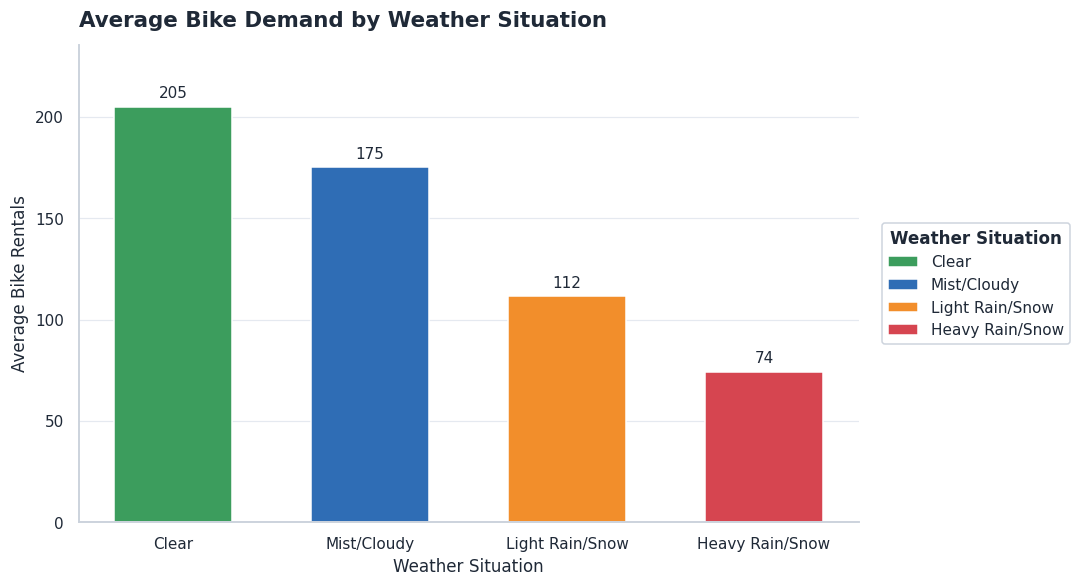

In [33]:
weather_demand = df.groupby('weather_label')['cnt'].mean().reindex(WEATHER_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(WEATHER_ORDER, weather_demand.values,
              color=[WEATHER_COLORS[w] for w in WEATHER_ORDER], edgecolor='white', width=0.6)
ax.bar_label(bars, labels=[f'{v:.0f}' if pd.notna(v) else '' for v in weather_demand.values],
             padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, weather_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Weather Situation', 'Weather Situation', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=WEATHER_COLORS[w], label=w) for w in WEATHER_ORDER],
           title='Weather Situation', outside=True)
plt.tight_layout()
plt.show()

### Feature Interaction Interpretation

The relationship between time of day and demand differs by working-day status. This indicates that fleet planning should consider both the hour and the type of day rather than relying on one fixed hourly pattern.

Temperature also shows a positive association with demand, although the observations are spread across the range.

Weather categories show clear differences in average demand.

### Demand Distribution by Weather Situation

A boxplot shows the full distribution of demand within each weather category, rather than only comparing category averages.

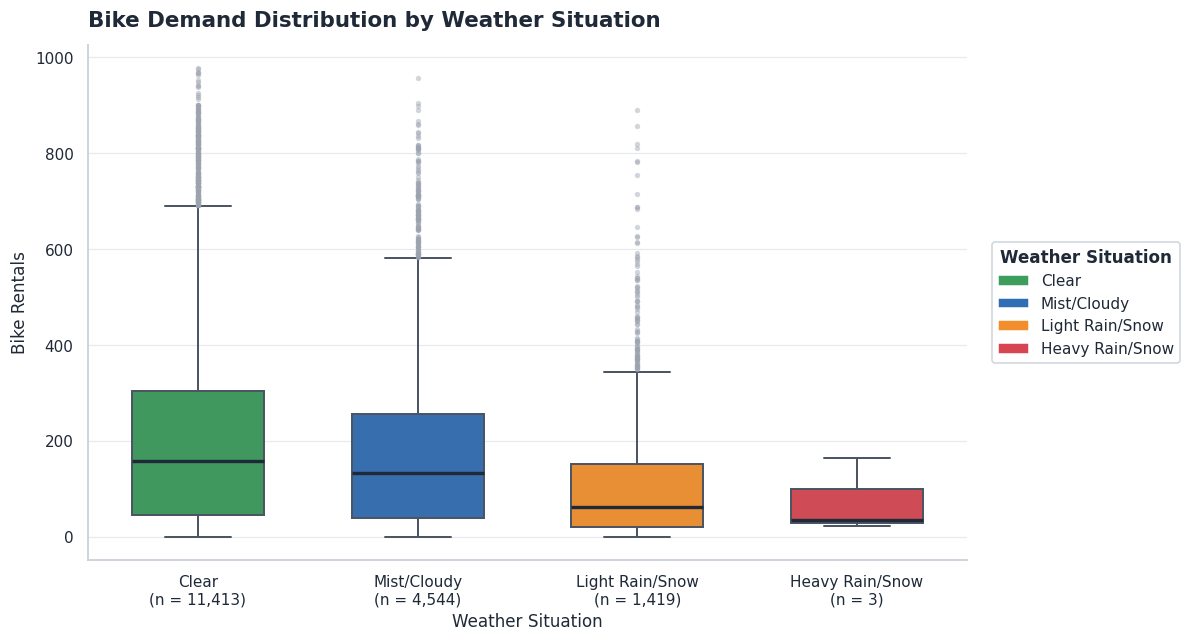

In [34]:
weather_order = [
    'Clear',
    'Mist/Cloudy',
    'Light Rain/Snow',
    'Heavy Rain/Snow'
]

# Sample size is shown under each category so the rare severe-weather groups are read carefully
weather_n = df['weather_label'].value_counts()
weather_tick_labels = [f"{w}\n(n = {weather_n.get(w, 0):,})" for w in weather_order]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df, x='weather_label', y='cnt', hue='weather_label',
    order=weather_order, hue_order=weather_order,
    palette=WEATHER_COLORS, legend=False, width=0.6, linewidth=1.3, saturation=0.9,
    linecolor='#4B5563',
    medianprops={'color': TEXT_DARK, 'linewidth': 2.2},
    flierprops={'marker': 'o', 'markerfacecolor': '#9CA3AF', 'markeredgecolor': 'none',
                'markersize': 3.5, 'alpha': 0.45},
    ax=ax
)
ax.set_xticks(range(len(weather_order)))
ax.set_xticklabels(weather_tick_labels)
style_axes(ax, 'Bike Demand Distribution by Weather Situation', 'Weather Situation', 'Bike Rentals')
add_legend(ax, [Patch(facecolor=WEATHER_COLORS[w], label=w) for w in weather_order],
           title='Weather Situation', outside=True)
plt.tight_layout()
plt.show()

### Weather Boxplot Interpretation

The boxplots allow comparison of the median, spread, and unusual demand observations across weather conditions. The rare severe-weather category should be interpreted cautiously because it contains far fewer observations than the more common weather categories.

## 10. Class / Category Distribution Impact

`weathersit` is used as the main categorical variable for distribution analysis.

Checking its distribution is important because highly imbalanced categories can make comparisons involving rare categories less reliable.

In [35]:
weather_counts = df['weathersit'].value_counts().sort_index()
weather_counts

,count
weathersit,
1,11413
2,4544
3,1419
4,3


In [36]:
weather_percentage = (
    df['weather_label']
    .value_counts(normalize=True)
    .reindex(['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow'])
    .mul(100)
)

weather_percentage

,proportion
weather_label,
Clear,65.671212
Mist/Cloudy,26.146499
Light Rain/Snow,8.165027
Heavy Rain/Snow,0.017262


### Class Distribution Interpretation

The weather categories are highly imbalanced.

Most observations belong to the clearer weather category, while severe weather observations are extremely rare.

Therefore, average demand for rare weather categories should be interpreted cautiously because they are based on much fewer observations.

## 11. Statistical EDA – Working vs Non-Working Days

An independent samples t-test is used to examine whether the average bike demand differs between working and non-working days.

A p-value below 0.05 is commonly used as evidence of a statistically significant difference.

In [37]:
working = df[df['workingday'] == 1]['cnt']
non_working = df[df['workingday'] == 0]['cnt']

t_stat, p_value = stats.ttest_ind(
    working,
    non_working,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.095067721524371
P-value: 4.249478377549554e-05


In [38]:
if p_value < 0.05:
    print("The difference in average demand between working and non-working days is statistically significant.")
else:
    print("The difference in average demand between working and non-working days is not statistically significant.")

The difference in average demand between working and non-working days is statistically significant.


## 12. Top 3 Actionable Data Insights

### Insight 1 – Hour and working-day status interact
Hourly demand patterns differ between working and non-working days. Fleet allocation should therefore consider both time of day and day type rather than using one fixed schedule.

### Insight 2 – Registered and casual riders use the system for different purposes
Registered rentals are concentrated in commuting-hour peaks on working days, while casual rentals are concentrated in the midday-to-afternoon hours and make up a larger share of demand on non-working days. Rebalancing should therefore prioritise commuter locations around working-day peak hours and leisure-oriented locations on non-working-day afternoons, rather than treating total demand as one uniform pattern.

### Insight 3 – Weather is associated with demand
Average demand decreases across poorer weather situations. Weather information can therefore be considered when planning fleet availability and rebalancing.

These insights describe patterns observed in the dataset and are intended to support operational planning.

## 13. Final EDA Summary

The EDA shows that:

- Bike demand is positively skewed, with some high-demand observations.
- High-demand observations should not automatically be treated as errors.
- Demand varies strongly by hour and season.
- Temperature has a positive association with total demand.
- Humidity and poorer weather conditions are associated with lower demand.
- Weather categories are highly imbalanced, especially the rare severe-weather category.
- Hour and working-day status show an important interaction.
- Registered riders follow commuting-hour peaks, while casual riders are more leisure-oriented.
- These patterns can support fleet rebalancing and demand-management decisions.